In [29]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time
import math
import os
import gc

from tensorflow.keras.applications.vgg19 import VGG19, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model


In [30]:
from google.colab import files
uploaded = files.upload()


Saving style.jpg to style (2).jpg
Saving content.jpg to content (2).jpg


In [31]:
def load_and_process_image(image_path, max_dim=256):
    img = load_img(image_path)
    long = max(img.size)
    scale = max_dim / long
    new_size = (round(img.size[0] * scale), round(img.size[1] * scale))
    img = img.resize(new_size)
    img = img_to_array(img)
    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)
    return img


In [32]:
def deprocess(img):
    img[:, :, 0] += 103.939
    img[:, :, 1] += 116.779
    img[:, :, 2] += 123.6
    img = img[:, :, ::-1]
    img = np.clip(img, 0, 255).astype('uint8')
    return img

def display_image(image):
    if len(image.shape) == 4:
        image = np.squeeze(image, axis=0)
    image = deprocess(image)
    plt.imshow(image)
    plt.axis('off')
    plt.show()


In [34]:
import tensorflow as tf

with tf.device('/CPU:0'):
    vgg = VGG19(include_top=False, weights='imagenet')
vgg.trainable = False


In [35]:
vgg = VGG19(include_top=False, weights='imagenet')
vgg.trainable = False


In [36]:
content_layer = 'block5_conv2'
style_layers = ['block1_conv1', 'block3_conv1', 'block5_conv1']

content_model = Model(inputs=vgg.input, outputs=vgg.get_layer(content_layer).output)

style_models = [
    Model(inputs=vgg.input, outputs=vgg.get_layer(layer).output)
    for layer in style_layers
]


In [37]:
def content_loss(content, generated):
    a_C = content_model(content)
    a_G = content_model(generated)
    return tf.reduce_mean(tf.square(a_C - a_G))

def gram_matrix(A):
    channels = int(A.shape[-1])
    a = tf.reshape(A, [-1, channels])
    n = tf.shape(a)[0]
    gram = tf.matmul(a, a, transpose_a=True)
    return gram / tf.cast(n, tf.float32)

weight_of_layer = 1. / len(style_models)

def style_cost(style, generated):
    J_style = 0
    for model in style_models:
        a_S = model(style)
        a_G = model(generated)
        GS = gram_matrix(a_S)
        GG = gram_matrix(a_G)
        layer_loss = tf.reduce_mean(tf.square(GS - GG))
        J_style += weight_of_layer * layer_loss
    return J_style

def content_cost(style, generated):
    J_content = 0
    for model in style_models:
        a_S = model(style)
        a_G = model(generated)
        GS = gram_matrix(a_S)
        GG = gram_matrix(a_G)
        layer_loss = tf.reduce_mean(tf.square(GS - GG))
        J_content += weight_of_layer * layer_loss
    return J_content


In [38]:
generated_images = []

def training_loop(content_path, style_path, iterations=30, a=10, b=1000):
    content = load_and_process_image(content_path)
    style = load_and_process_image(style_path)
    generated = tf.Variable(content, dtype=tf.float32)

    opt = tf.keras.optimizers.Adam(learning_rate=0.5)
    best_cost = math.inf
    best_image = None

    for i in range(iterations):
        start = time.time()
        with tf.GradientTape() as tape:
            J_content = content_cost(style, generated)
            J_style = style_cost(style, generated)
            J_total = a * J_content + b * J_style

        grads = tape.gradient(J_total, generated)
        opt.apply_gradients([(grads, generated)])

        if J_total < best_cost:
            best_cost = J_total
            best_image = generated.numpy()

        print(f"Iteration {i+1}, Loss: {J_total.numpy():.2e}, Time: {time.time() - start:.2f}s")
        generated_images.append(generated.numpy())

    return best_image


In [39]:
tf.keras.backend.clear_session()
gc.collect()


0

In [43]:
final_image = training_loop('content.jpg', 'style.jpg', iterations=30)


Iteration 1, Loss: 9.40e+11, Time: 0.36s
Iteration 2, Loss: 8.61e+11, Time: 0.38s
Iteration 3, Loss: 7.84e+11, Time: 0.33s
Iteration 4, Loss: 7.12e+11, Time: 0.31s
Iteration 5, Loss: 6.47e+11, Time: 0.31s
Iteration 6, Loss: 5.89e+11, Time: 0.38s
Iteration 7, Loss: 5.37e+11, Time: 0.57s
Iteration 8, Loss: 4.92e+11, Time: 0.56s
Iteration 9, Loss: 4.51e+11, Time: 0.60s
Iteration 10, Loss: 4.16e+11, Time: 0.44s
Iteration 11, Loss: 3.85e+11, Time: 0.46s
Iteration 12, Loss: 3.57e+11, Time: 0.77s
Iteration 13, Loss: 3.33e+11, Time: 0.98s
Iteration 14, Loss: 3.11e+11, Time: 0.91s
Iteration 15, Loss: 2.92e+11, Time: 1.20s
Iteration 16, Loss: 2.74e+11, Time: 0.69s
Iteration 17, Loss: 2.58e+11, Time: 0.67s
Iteration 18, Loss: 2.44e+11, Time: 0.61s
Iteration 19, Loss: 2.31e+11, Time: 0.61s
Iteration 20, Loss: 2.19e+11, Time: 0.86s
Iteration 21, Loss: 2.08e+11, Time: 0.47s
Iteration 22, Loss: 1.98e+11, Time: 0.57s
Iteration 23, Loss: 1.89e+11, Time: 0.53s
Iteration 24, Loss: 1.81e+11, Time: 0.30s
I

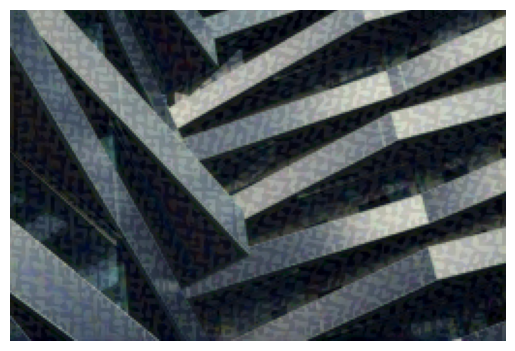

In [44]:
display_image(final_image)
